In [1]:
import numpy as np
import matplotlib.pyplot as plt
import load_mnist

In [2]:
# load data using functions coded in load_mnist.py
X_train = load_mnist.load_images(load_mnist.f_training_images)
y_train = load_mnist.load_labels(load_mnist.f_training_labels)

X_test = load_mnist.load_images(load_mnist.f_test_images)
y_test = load_mnist.load_labels(load_mnist.f_test_labels)

In [3]:
def train_ridge_classifier(X, y, lam):
    """ridge-regularized LS classifier for a match with the supplied digit
    the basic formula is w=(X.T@X)^(-1)X^Ty, but we create y as a membership matrix    
    """
    # create a matrix for y, where columns yj contain a 1 if yi=j, -1 if yi<>j
    y_mat = load_mnist.digit_2_matrix(y)
    
    # calculate weights using ridge regularizer
    w = np.linalg.inv(X.T@X + (lam * np.eye(X.shape[1])))@X.T@y_mat
    
    return w

In [4]:
# weight matrix m-rows x 10-cols, column represents weights for classifying that digit
w = train_ridge_classifier(X_train, y_train, 0.001)

y_hat = load_mnist.matrix_2_digit(X_train@w)

n = 10
correct = y_hat==y_train
print(np.hstack((y_hat[:n], y_train[:n], correct[:n])))

print(1-np.sum(correct[:n])/n)

error_rate = 1-np.sum(y_hat==y_train) / len(y_train)
print(error_rate)

[[5. 5. 1.]
 [0. 0. 1.]
 [4. 4. 1.]
 [1. 1. 1.]
 [9. 9. 1.]
 [2. 2. 1.]
 [1. 1. 1.]
 [3. 3. 1.]
 [1. 1. 1.]
 [4. 4. 1.]]
0.0
0.14806666666666668


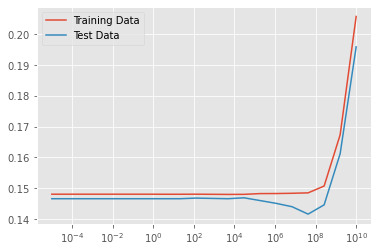

In [5]:
lam_arr = np.logspace(-5,10,20)
err_train = np.zeros(len(lam_arr))
err_test = np.zeros(len(lam_arr))

for i, lam in enumerate(lam_arr):
    
    # train the model using the training set
    w = train_ridge_classifier(X_train, y_train, lam)
    
    # demonstrate the model error with the training data
    y_hat = load_mnist.matrix_2_digit(X_train@w)
    err_train[i] = 1 - np.sum(y_hat==y_train) / len(y_train)
    
    # use the test set to measure error
    y_hat = load_mnist.matrix_2_digit(X_test@w)
    err_test[i] = 1 - np.sum(y_hat==y_test) / len(y_test)
    
plt.plot(lam_arr, err_train, label='Training Data')
plt.plot(lam_arr, err_test, label='Test Data')
plt.semilogx()
plt.legend()